# Graph Convolutional Network to Overcome Navigation Challenges

By: Apurvata Kumar

Updated: March 2026

In [317]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.preprocessing import MinMaxScaler
import networkx as nx
import matplotlib.pyplot as plt

Change below file paths as needed.

In [318]:
# Import customized datasets
simple_file = '/content/custom_data_simple.csv'
# For both medium and complex datasets
complex_file = '/content/custom_data_complex.csv'

Using three types of datasets for three phases. I am commenting out the others when one dataset is in use.

Use country code/latitude/longitude keywords for the medium and complex dataset.

In [319]:
# Create dataset for "simple" phase
df = pd.read_csv(simple_file).iloc[2:53]

# Convert longitude and latitude to integer for simple phase
df['usa_state_longitude'] = df['usa_state_longitude'].fillna(0).astype(int)
df['usa_state_latitude'] = df['usa_state_latitude'].fillna(0).astype(int)

# Select 5 rows at random for 10 different sets (8 for training and 2 for testing)
df_simple1 = df.sample(n=5)
df_simple2 = df.sample(n=5)
df_simple3 = df.sample(n=5)
df_simple4 = df.sample(n=5)
df_simple5 = df.sample(n=5)
df_simple6 = df.sample(n=5)
df_simple7 = df.sample(n=5)
df_simple8 = df.sample(n=5)
# For testing
df_simple9 = df.sample(n=5)
df_simple10 = df.sample(n=5)

display(df_simple1)
display(df_simple2)

,usa_state_code,usa_state_latitude,usa_state_longitude
11,HI,19,-155
25,MS,32,-89
24,MO,37,-91
30,NH,43,-71
41,SC,33,-81


,usa_state_code,usa_state_latitude,usa_state_longitude
40,RI,41,-71
50,WV,38,-80
27,NC,35,-79
9,FL,27,-81
30,NH,43,-71


In [320]:
# Create dataset for "medium" phase
df = pd.read_csv(complex_file).iloc[2:246]

# Select 10 rows at random for 10 different sets (8 for training and 2 for testing)
df_medium1 = df.sample(n=10)
df_medium2 = df.sample(n=10)
df_medium3 = df.sample(n=10)
df_medium4 = df.sample(n=10)
df_medium5 = df.sample(n=10)
df_medium6 = df.sample(n=10)
df_medium7 = df.sample(n=10)
df_medium8 = df.sample(n=10)
# For testing
df_medium9 = df.sample(n=10)
df_medium10 = df.sample(n=10)

display(df_medium1)
display(df_medium2)

,country_code,country_latitude,country_longitude
155,MZ,-18.665695,35.529562
27,BO,-16.290154,-63.588653
84,GQ,1.650801,10.267895
62,EH,24.215527,-12.885834
173,PH,12.879721,121.774017
234,VI,18.335765,-64.896335
167,NZ,-40.900557,174.885971
5,AL,41.153332,20.168331
82,GN,9.945587,-9.696645
108,JE,49.214439,-2.131250


,country_code,country_latitude,country_longitude
130,LT,55.169438,23.881275
84,GQ,1.650801,10.267895
62,EH,24.215527,-12.885834
198,SK,48.669026,19.699024
37,CD,-4.038333,21.758664
104,IQ,33.223191,43.679291
89,GW,11.803749,-15.180413
109,JM,18.109581,-77.297508
49,CV,16.002082,-24.013197
153,MX,23.634501,-102.552784


In [321]:
# Create dataset for "complex" phase
df = pd.read_csv(complex_file).iloc[2:246]

# Select 25 rows at random for 10 different sets (8 for training and 2 for testing)
df_complex1 = df.sample(n=25)
df_complex2 = df.sample(n=25)
df_complex3 = df.sample(n=25)
df_complex4 = df.sample(n=25)
df_complex5 = df.sample(n=25)
df_complex6 = df.sample(n=25)
df_complex7 = df.sample(n=25)
df_complex8 = df.sample(n=25)
# For testing
df_complex9 = df.sample(n=25)
df_complex10 = df.sample(n=25)

display(df_complex1)
display(df_complex2)

,country_code,country_latitude,country_longitude
111,JP,36.204824,138.252924
192,SD,12.862807,30.217636
200,SM,43.942360,12.457777
212,TH,15.870032,100.992541
97,HU,47.162494,19.503304
119,KR,35.907757,127.766922
218,TO,-21.178986,-175.198242
215,TL,-8.874217,125.727539
244,ZW,-19.015438,29.154857
7,AN,12.226079,-69.060087


,country_code,country_latitude,country_longitude
119,KR,35.907757,127.766922
229,UZ,41.377491,64.585262
144,MO,22.198745,113.543873
120,KW,29.311660,47.481766
88,GU,13.444304,144.793731
39,CG,-0.228021,15.827659
147,MR,21.007890,-10.940835
167,NZ,-40.900557,174.885971
36,CC,-12.164165,96.870956
124,LB,33.854721,35.862285


If any of the data points are null, we can rerun the code to regenerate random values that are not null.

***For the below code, the dataset can be changed to other simple or complex sets created above.***

As an example, only one dataset is used for the program.

In [322]:
# Pick a dataset
data = df_simple1.copy()

In [323]:
# Normalize datasets between the range [0, 1] using MinMaxScalar
scaler = MinMaxScaler()

df_simple1_norm = data.copy()
columns = ['usa_state_latitude', 'usa_state_longitude']
df_simple1_norm[columns] = scaler.fit_transform(df_simple1_norm[columns])

display(df_simple1_norm)

,usa_state_code,usa_state_latitude,usa_state_longitude
11,HI,0.000000,0.000000
25,MS,0.541667,0.785714
24,MO,0.750000,0.761905
30,NH,1.000000,1.000000
41,SC,0.583333,0.880952


In [324]:
# Convert (longitude, latitude) to cartesian coordinates (x, y)
df_simple1_cart = df_simple1_norm.copy()
df_simple1_cart['x'] = df_simple1_norm['usa_state_longitude']
df_simple1_cart['y'] = df_simple1_norm['usa_state_latitude']

df_simple1_cart = df_simple1_cart[['usa_state_code', 'x', 'y']].copy()

display(df_simple1_cart)

,usa_state_code,x,y
11,HI,0.000000,0.000000
25,MS,0.785714,0.541667
24,MO,0.761905,0.750000
30,NH,1.000000,1.000000
41,SC,0.880952,0.583333


This step converts the imported dataset into a custom normalized version using cartesian coordinates with values between 0 and 1.

In [325]:
# Add random noise to reduce overfitting
noise_val = 0.0003

df_simple1_cart['x'] = df_simple1_cart['x'] + np.random.normal(0, noise_val, size=len(data))
df_simple1_cart['y'] = df_simple1_cart['y'] + np.random.normal(0, noise_val, size=len(data))

display(df_simple1_cart)

,usa_state_code,x,y
11,HI,0.000214,0.000317
25,MS,0.785628,0.541626
24,MO,0.761859,0.750114
30,NH,1.000110,0.999964
41,SC,0.880710,0.583420


After dataset is customized, the nodes (state or country codes) can be represented as a graph with edges (distance between nodes).

In [326]:
# Set the customized/normalized dataset as the new data variable
data_custom = df_simple1_cart.copy()

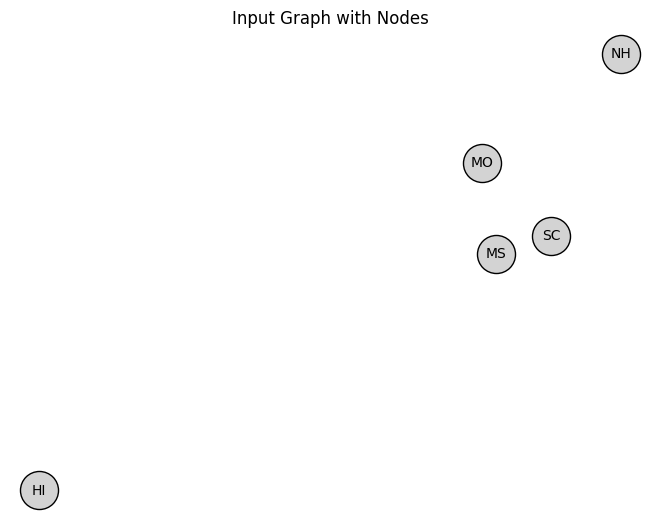

,usa_state_code,x,y
11,HI,0.000214,0.000317
25,MS,0.785628,0.541626
24,MO,0.761859,0.750114
30,NH,1.000110,0.999964
41,SC,0.880710,0.583420


In [327]:
# Build a simple graph for the input
G = nx.Graph()

# Use state code as nodes
for id, row in data_custom.iterrows():
    G.add_node(row['usa_state_code'], pos=(row['x'], row['y']))

info = data_custom[['usa_state_code', 'x', 'y']]
pos = nx.get_node_attributes(G, 'pos')

nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=750, font_size=10, font_color='black', edgecolors='black')
plt.title('Input Graph with Nodes')
plt.show()

display(info)

Calculate the distance between nodes using the "Distance Formula":

***d = sqrt((x2 - x1)^2 + (y2 - y1)^2)***

Note: The distance is inversed because farther distance has lower weights on the edges.

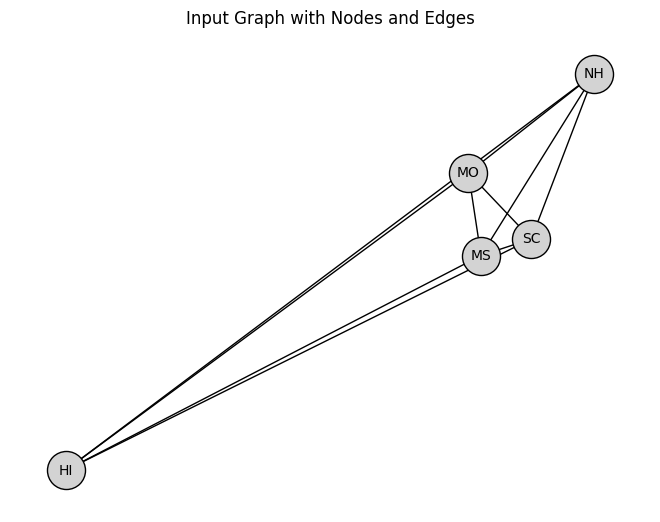

,usa_state_code,x,y
11,HI,0.000214,0.000317
25,MS,0.785628,0.541626
24,MO,0.761859,0.750114
30,NH,1.000110,0.999964
41,SC,0.880710,0.583420


In [328]:
# Add edges based on the distance (inverse) between nodes
for i in range(len(info)):
  for j in range(i+1, len(info)):
    x1 = info.iloc[i]['x']
    x2 = info.iloc[j]['x']
    y1 = info.iloc[i]['y']
    y2 = info.iloc[j]['y']

    # Distance between nodes
    d = np.sqrt((x1-x2)**2 + (y1-y2)**2)

    # Weight of edges (inverse of distance = the farther the node, the lower the weight)
    w = 1/d if d>0 else 0

    G.add_edge(info.iloc[i]['usa_state_code'], info.iloc[j]['usa_state_code'], weight=w)

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=750, font_size=10, font_color='black', edgecolors='black')
plt.title('Input Graph with Nodes and Edges')
plt.show()

display(info)

Adding weights directly to the graph's edges. This is different than the weights/bias parameters in neural networks.

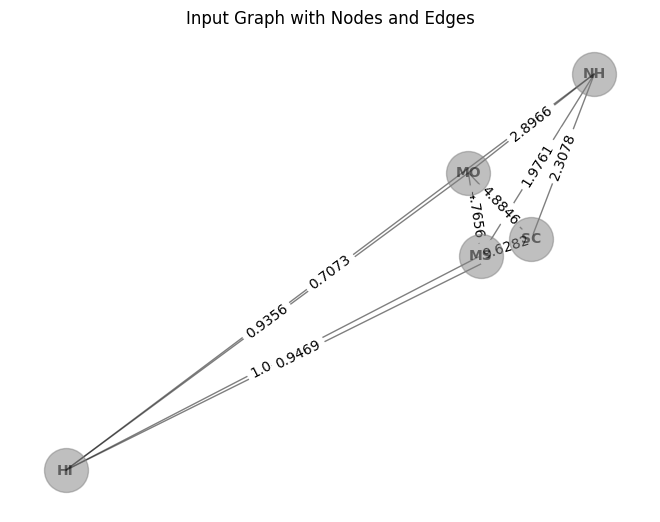

{('HI', 'MS'): np.float64(1.0483465441405917),
 ('HI', 'MO'): np.float64(0.9356428225425314),
 ('HI', 'NH'): np.float64(0.7072680756041871),
 ('HI', 'SC'): np.float64(0.9469071637674698),
 ('MS', 'MO'): np.float64(4.765588338515351),
 ('MS', 'NH'): np.float64(1.9761317326879408),
 ('MS', 'SC'): np.float64(9.628223169790948),
 ('MO', 'NH'): np.float64(2.896557584916085),
 ('MO', 'SC'): np.float64(4.884605501242247),
 ('NH', 'SC'): np.float64(2.3077695947972794)}

In [329]:
from numpy.random.mtrand import f
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_color='black', font_weight='bold', edge_color='black', alpha=0.5)

# Add weights to the graph's edges
edge_attributes = nx.get_edge_attributes(G, 'weight')
edge_labels_attributes = {k: f'{v:.4f}' for k, v in edge_attributes.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_attributes, font_color='black', font_size=10)

plt.title('Input Graph with Nodes and Edges')
plt.show()

# Show the edge weights
display(nx.get_edge_attributes(G, 'weight'))


Add random noise and remove 2-3 random edges to make it suitable for the input graph.

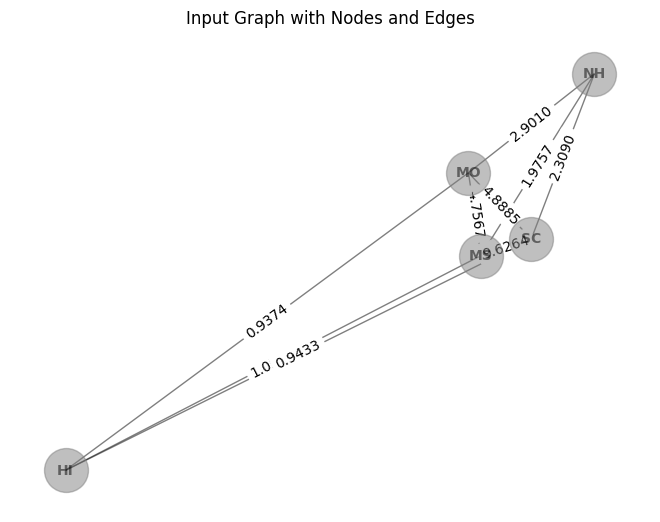

{('HI', 'MS'): np.float64(1.0539073373522885),
 ('HI', 'MO'): np.float64(0.9373745138202855),
 ('HI', 'SC'): np.float64(0.9432792104366544),
 ('MS', 'MO'): np.float64(4.756672052905338),
 ('MS', 'NH'): np.float64(1.9757484722917715),
 ('MS', 'SC'): np.float64(9.626439130473097),
 ('MO', 'NH'): np.float64(2.9009928584893663),
 ('MO', 'SC'): np.float64(4.888547050654772),
 ('NH', 'SC'): np.float64(2.3090206140043668)}

In [334]:
# Variables
random_noise = 0.003
edges_to_remove = 3
edge_threshold = 0.75
i = 0

# Remove "random_edges_to_remove" number of edges from the graph
while i < edges_to_remove:
  # Collect edges to remove
  collect_edges = []
  for u, v, data in G.edges(data=True):
    # Remove only edges that are less than "edge_threshold" because distance is too far
    if data['weight'] < edge_threshold:
      collect_edges.append((u, v))
    # If not removed, add random noise
    else:
      data['weight'] = data['weight'] + np.random.normal(0, random_noise)
    i+=1
  G.remove_edges_from(collect_edges)


# Draw graph again

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_color='black', font_weight='bold', edge_color='black', alpha=0.5)

# Add weights to the graph's edges
edge_attributes = nx.get_edge_attributes(G, 'weight')
edge_labels_attributes = {k: f'{v:.4f}' for k, v in edge_attributes.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_attributes, font_color='black', font_size=10)

plt.title('Input Graph with Nodes and Edges')
plt.show()

# Show the edge weights
display(nx.get_edge_attributes(G, 'weight'))



Find two random rows for source and destination for the input. If 0, retry the code until both are not null.

In [340]:
# Pick 2 random nodes

# Input Source
source = np.random.randint(0, len(data_custom))
# Input Destination
dest = np.random.randint(0, len(data_custom))

display(source, dest)

source_node = data_custom.iloc[source]
dest_node = data_custom.iloc[dest]

display(source_node, dest_node)

3

4

,30
usa_state_code,NH
x,1.00011
y,0.999964


,41
usa_state_code,SC
x,0.88071
y,0.58342
